## Tools


In [7]:
from langchain.tools import tool
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [8]:
model = init_chat_model("groq:qwen/qwen3.6-27b")
response = model.invoke("Why do parrots talk?")
response

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Understand User Question**: The user asks "Why do parrots talk?" This is a straightforward question about animal behavior, specifically parrot vocalization and speech mimicry.\n\n2.  **Identify Key Concepts**:\n   - Parrot vocal anatomy (syrinx)\n   - Social behavior and communication needs\n   - Mimicry as a social bonding tool\n   - Cognitive abilities (intelligence, learning capacity)\n   - Evolutionary reasons (survival, flock cohesion, mate attraction)\n   - Human interaction (captivity vs. wild)\n\n3.  **Structure the Answer**:\n   - Introduction: Briefly state that parrots talk due to a combination of physical, cognitive, and social factors.\n   - Physical capability: Explain the syrinx and vocal tract.\n   - Social/behavioral reasons: Mimicry for bonding, flock cohesion, communication.\n   - Cognitive aspects: High intelligence, learning through association.\n   - Evolutionary context: Why these traits developed

### This is how to initialize a tool in langchain. There is "@tool" decorator function. 

In [4]:
@tool
def get_weather(location:str) -> str:
    """Get the weather at a location"""
    return f"It is sunny in {location}"

In [9]:
# Bind the model
# 1st way

model_with_tools = model.bind_tools([get_weather])

In [12]:
response = model_with_tools.invoke("What is the weather like in Boston?")
print(response)

for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

content='' additional_kwargs={'reasoning_content': 'Thinking Process:\n1.  Identify the user\'s intent: The user is asking for the current weather in a specific location.\n2.  Identify the location: Boston.\n3.  Check available tools: `get_weather` function is available.\n4.  Determine required parameters: `location` (string).\n5.  Call the function: `get_weather(location="Boston")`.\n6.  Formulate response based on the function\'s output. Wait, I need to actually call the tool first. I will generate the tool call.✅\n7.  Output matches the required format.📝\n', 'tool_calls': [{'id': 'jcfjafwp7', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 276, 'total_tokens': 433, 'completion_time': 0.302175624, 'completion_tokens_details': {'reasoning_tokens': 129}, 'prompt_time': 0.021775528, 'prompt_tokens_details': None, 'queue_time': 0.047340552, 'total_time': 0.323951

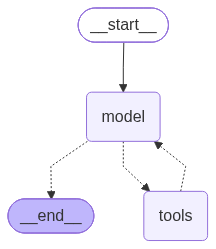

In [13]:
# 2nd Way

from langchain.agents import create_agent
agent = create_agent(
    model = "groq:qwen/qwen3.6-27b",
    tools=[get_weather],
    system_prompt="You have a 30 year experience in the scope of weather assistance"
)
agent

### Tool Execution Loops

In [14]:
# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)
# "The current weather in Boston is 72°F and sunny."

It is currently sunny in Boston.


In [15]:
messages

[{'role': 'user', 'content': "What's the weather in Boston?"},
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Thinking Process:\n1.  Identify the user\'s intent: The user wants to know the weather in Boston.\n2.  Identify the available tool: `get_weather` function.\n3.  Check required parameters: `location` (string) is required.\n4.  Extract parameter value: "Boston".\n5.  Call the function: `get_weather(location="Boston")`.\n6.  Formulate response based on the function\'s output. (I will simulate the tool call now). \n\nWait, I need to generate the actual tool call.\nParameters: `{"location": "Boston"}`\nCall: `get_weather(location="Boston")`\nProceed. \nSelf-Correction/Verification: The prompt gives a specific tool schema. I will use it exactly.\nTool: `get_weather`\nArgument: `location`: "Boston"\nOutput matches schema. Ready. \nProceeds. \n[Output Generation] -> calls tool. \n(Note: I am an AI, I will generate the tool call as requested.) \n`print(get_weather(locat